In [140]:
# !pip install numpy
# !pip install scikit-learn
# !pip install panda
# !pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets  import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)

df = pd.DataFrame(X, columns=["X"])
df["y"] = y

print(df.info())
print(df.describe())

X = np.asarray(df['X'], dtype='float32')
y = np.asarray(df['y'], dtype='float32')

df


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       100 non-null    float64
 1   y       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
None
                X           y
count  100.000000  100.000000
mean    -0.103847   -3.449530
std      0.908168   41.321720
min     -2.619745 -118.027454
25%     -0.600906  -30.170786
50%     -0.126956   -0.634702
75%      0.405952   23.478589
max      1.852278   89.033145


,X,y
0,0.931280,50.779929
1,0.087047,-10.065270
2,-1.057711,-34.918392
3,0.314247,10.526743
4,-0.479174,-17.738377
...,...,...
95,1.852278,78.085079
96,-1.424748,-70.968483
97,-0.719844,-38.902213
98,-0.072010,4.339229


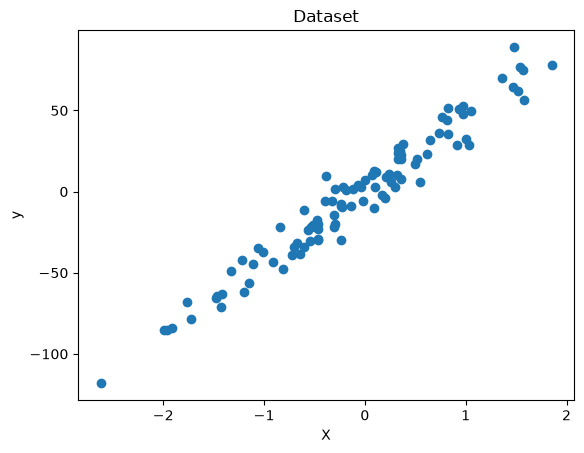

In [141]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset")
plt.show()

In [ ]:
def hypothesis(x, w, b):
    return (w * x) + b

def cost(w, b):
    m = len(X)
    cost_sum = 0

    for i in range(m):
        x_i = X[i]
        y_i = y[i]
        y_pred = hypothesis(x_i, w, b)
        loss = y_pred - y_i
        cost_sum += loss ** 2

    return cost_sum / (2 * m)

def compute_gradients(w, b, lr):
    m = len(X)

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        x_i = X[i]
        y_i = y[i]
        y_pred = hypothesis(x_i, w, b)
        loss = y_pred - y_i

        dj_dw += loss * x_i
        dj_db += loss

    new_w = w - (lr * dj_dw / m)
    new_b = b - (lr * dj_db / m)

    return new_w, new_b


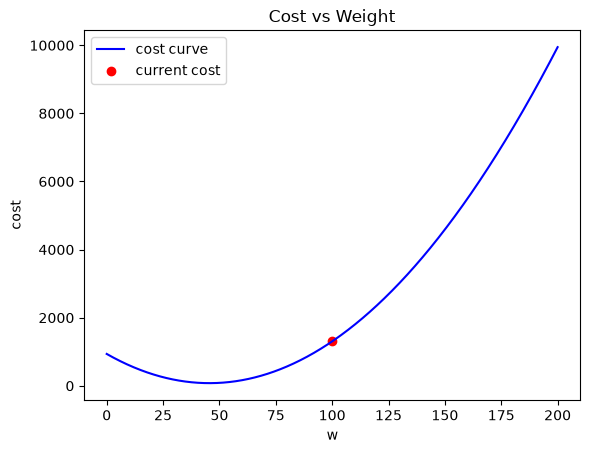

In [143]:
def visualize_cost_curve(w, b):
    W_tmp = np.linspace(0, w * 2, 1000)
    cost_tmp = np.array([cost(w, b) for w in W_tmp])

    plt.plot(W_tmp, cost_tmp, c='b', label='cost curve')
    plt.scatter(w, cost(w, b), c='r', label='current cost')
    plt.xlabel('w')
    plt.ylabel('cost')
    plt.title('Cost vs Weight')
    plt.legend()
    plt.show()


visualize_cost_curve(100, 10)

iteration 0 1302.081 100 10
iteration 100 1114.1494 95.67305 9.686373
iteration 200 954.41315 91.68662 9.361541
iteration 300 818.59827 88.01355 9.029806
iteration 400 703.0884 84.628914 8.694794
iteration 500 604.8194 81.50978 8.35955
iteration 600 521.19525 78.6351 8.026622
iteration 700 450.01367 75.98545 7.6981063
iteration 800 389.40784 73.543 7.375713
iteration 900 337.7949 71.2914 7.0608287
iteration 1000 293.82922 69.21552 6.754549
iteration 1100 256.36893 67.30148 6.45772
iteration 1200 224.44676 65.536644 6.1709824
iteration 1300 197.23732 63.909176 5.894787
iteration 1400 174.04044 62.408287 5.6294346
iteration 1500 154.2608 61.02404 5.375096
iteration 1600 137.39188 59.747253 5.131829
iteration 1700 123.00296 58.569523 4.899597
iteration 1800 110.72743 57.48308 4.678292
iteration 1900 100.25337 56.48079 4.467741
iteration 2000 91.31481 55.556038 4.2677174
iteration 2100 83.68597 54.70282 4.077955
iteration 2200 77.17396 53.915535 3.8981562
iteration 2300 71.61456 53.189045 

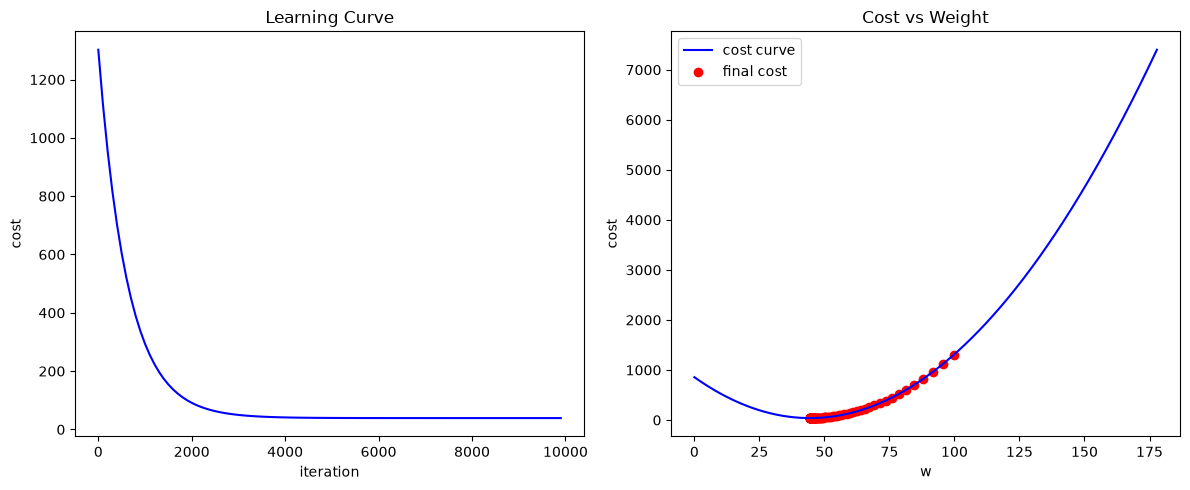

In [ ]:
def visualize_learning_curve(w, b, lr):

    iter_his = []
    cost_his = []
    w_his = []

    initial_cost = cost(w, b)
    iteration = 10000

    for i in range(iteration):
        new_w, new_b = compute_gradients(w, b, lr)
        new_cost = cost(new_w, new_b)

        if abs(new_cost-initial_cost) > 1e-6:
            break

        if (i % 100 == 0):
            print('iteration', i, new_cost, w, b)
            iter_his.append(i)
            cost_his.append(new_cost) 
            w_his.append(w)

        initial_cost = new_cost
        w, b = new_w, new_b

    print('Final', w, b, initial_cost)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(iter_his, cost_his, c='b')
    plt.xlabel('iteration')
    plt.ylabel('cost')
    plt.title('Learning Curve')

    W_tmp = np.linspace(0, w * 4, 1000)
    cost_tmp = np.array([cost(w_val, b) for w_val in W_tmp]) 

    plt.subplot(1, 2, 2)
    plt.plot(W_tmp, cost_tmp, c='b', label='cost curve')
    plt.scatter(w_his, cost_his, c='r', label='final cost')
    plt.xlabel('w')
    plt.ylabel('cost')
    plt.title('Cost vs Weight')
    plt.legend()

    plt.tight_layout()
    plt.show()


visualize_learning_curve(100, 10, 0.001)